# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets_e, datasets_a, datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders, mapping_minor_2_major

from ciim.src.tf_activity.helper import retrieve_adata, retrieve_feature_data, retrieve_net, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_valid_stats

from ciim.src.tf_activity.plots import plot_net_nx, plot_sig_tfs_stats

from ciim.src.utils.plots import dotplot
# from ciim.src.tf_activity.helper import retreive_stats

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df

# Some funcs or unknown sections

In [3]:
def compile_data(cell_type, target_tfs, target_filter_criteria='in_degree_c'):
    stats_tf = stats_valid[(stats_valid['cell_type']==cell_type) & (stats_valid['tf'].isin(target_tfs))]
    stats_targets = stats_targets_all[stats_targets_all['cell_type']==cell_type]
    net = consensus_nets_dict[cell_type]
    print('Put the data together ...')
    data_all = obj.wrapper_retreive_stats(stats_tf, stats_targets, net, filter_criteria=target_filter_criteria,
                n_top_targets=20)
    return data_all
if False:
    from ciim.src.tf_activity.plots import DotPlotTFtarget

    obj = DotPlotTFtarget(tf_all, skeleton)
    obj.plot_legend()
    data = compile_data(cell_type, sig_tfs_ts_sorted, target_filter_criteria='meta_p_adj_target')
    obj.plot_dotplot(data, 
                    figsize=(6, 5), 
                    height_ratios=(4, .3), 
                    width_ratios=[0.2, 4], 
                    ax_main_margin=(0.04, .1),
                    title=f"Common TFs to T cells: {cell_type}")
    # - store the net
    net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
    net_dicts[cell_type] = net



## Compare nets

In [111]:
# from ciim.src.tf_activity.plots import compare_nets_interaction
if True:
    net_store = []
    for cell_type in cell_types:
        for dataset in datasets_all:
            net = retrieve_net(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            print(f'net: {cell_type} {dataset} ', net.shape)
            net_store.append(net)
    nets_all = pd.concat(net_store)

net: CD4T data1  (3695, 11)
net: CD4T data7_allTPs_jalil  (10233, 11)
net: CD4T data12  (12399, 11)
net: CD4T SLE_European  (1503, 10)
net: CD4T data13_Korean  (14878, 10)
net: CD4T data13_Japanese  (11619, 10)
net: CD4T SLE_Asian  (1783, 10)
net: CD8T data1  (7529, 11)
net: CD8T data7_allTPs_jalil  (28061, 11)
net: CD8T data12  (24551, 11)
net: CD8T SLE_European  (3605, 10)
net: CD8T data13_Korean  (67867, 10)
net: CD8T data13_Japanese  (48566, 10)
net: CD8T SLE_Asian  (3130, 10)
net: NK data1  (1352, 11)
net: NK data7_allTPs_jalil  (6739, 11)
net: NK data12  (3251, 11)
net: NK SLE_European  (669, 10)
net: NK data13_Korean  (8661, 10)
net: NK data13_Japanese  (5023, 10)
net: NK SLE_Asian  (931, 10)
net: B data1  (71655, 11)
net: B data7_allTPs_jalil  (18866, 11)
net: B data12  (13403, 11)
net: B SLE_European  (1031, 10)
net: B data13_Korean  (26700, 10)
net: B data13_Japanese  (12631, 10)
net: B SLE_Asian  (1404, 10)
net: MONO data1  (47923, 11)
net: MONO data7_allTPs_jalil  (62153, 1

        SLE_Asian  SLE_European  data1  data12  data13_Japanese  \
SPI1        False         False  False    True            False   
ZNF207       True          True  False    True             True   
MBNL2       False         False  False    True             True   
ZNF263      False         False  False   False            False   
TSHZ2        True          True   True    True             True   
...           ...           ...    ...     ...              ...   
GABPA       False         False  False   False            False   
ZNF451      False         False  False   False             True   
IKZF5       False         False  False   False            False   
ZNF430      False         False  False    True            False   
ADNP        False         False  False   False            False   

        data13_Korean  data7_allTPs_jalil  
SPI1            False               False  
ZNF207           True                True  
MBNL2            True                True  
ZNF263          Fal

IndexError: index -1 is out of bounds for axis 0 with size 0

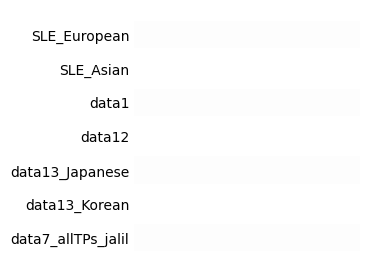

In [ ]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
if True:
    # for source
    to_show='source'

    if to_show=='source':
        min_subset_size=100
        min_degree=1
    if to_show=='target':
        min_subset_size=10
        min_degree=2
    if to_show=='edge':
        min_subset_size=100
        min_degree=2


    for cell_type in cell_types:
        nets = nets_all[nets_all['cell_type']==cell_type]
        # edges
        df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

        interaction_df = create_interaction_df(df_dict)
        # print(interaction_df)
        # interaction_df.columns = interaction_df.columns.map(surrogate_names)
        aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
        plt.title(cell_type)

# Bulk main

## Heatmap of sig TFs across cell types and cohorts

In [63]:
# - read all stats (with and without significance) and add is_significant to mark the significant ones
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')

# - add sig signs for e
stats_e = retrieve_sig_stats(type, race='european')
tuple_index = stats_e.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all.reset_index(inplace=True)

# - add sig signs
stats_a = retrieve_sig_stats(type, race='asian')
tuple_index = stats_a.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf'])
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all.reset_index(inplace=True)

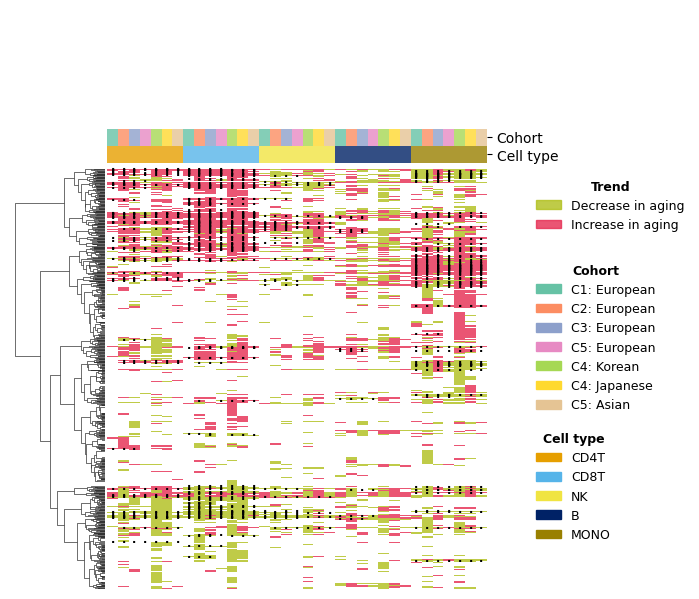

In [64]:
from ciim.src.tf_activity.plots import plot_overall_heatmap


stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor_col2=(1.1, .8),
                    figsize=(6, 8),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Cohort'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Intersection of races

{'CREB3L2', 'RARA', 'KLF10', 'FOXP3', 'FOXN3', 'EEA1', 'SOX4', 'NFKB2', 'ARHGAP35', 'IKZF3', 'MYBL1', 'ZNF831', 'STAT1', 'ZBTB1', 'DRAP1', 'IKZF2'}
{'CREB3L2', 'ZNF677', 'JAZF1', 'PLAG1', 'ELK3', 'TFAP4', 'KLF7', 'SCML4', 'FOSB', 'FOXO1', 'TFEB', 'ZSCAN18', 'TGIF1', 'MTERF4', 'NFKB2', 'ZNF581', 'SMAD3', 'SREBF1', 'MSC', 'ZNF814', 'HMGN3', 'STAT1', 'ARNTL', 'SOX4', 'ZNF439', 'SETBP1', 'ZNF831', 'ELF1', 'GFI1', 'IKZF2', 'HOXB4', 'NME2', 'ZMAT1', 'CC2D1A', 'E2F3', 'ZNF600', 'SP110'}
{'FOS', 'BNC2', 'NME2', 'TCF4', 'CEBPB', 'ATF4', 'SOX4', 'EOMES', 'BAZ2B', 'IRF8', 'BATF', 'ZNF683', 'IRF9', 'ETS1', 'ZNF292', 'HMGA1', 'LEF1', 'FOXP1'}
{'ZNF318', 'BAZ2A', 'HIF1A', 'SOX4', 'RUNX3', 'IKZF3', 'ZNF292', 'ZBTB20', 'ZNF644', 'BBX'}
{'ZNF428', 'ARID5B', 'CEBPB', 'TCF4', 'ETS2', 'FOXN3', 'SAFB', 'ZNF207', 'SP110', 'IRF7', 'GPBP1L1', 'HMGA1', 'NFIL3', 'MXD4', 'CEBPA', 'SP140'}


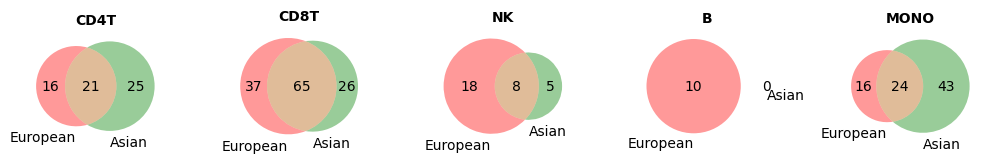

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Collect stats as sets of significant TFs for each analysis and cell type
stats_e = retrieve_sig_stats(type, race='european')
stats_a = retrieve_sig_stats(type, race='asian')


fig, axes = plt.subplots(1, len(cell_types), figsize=(2 * len(cell_types), 2))

if len(cell_types) == 1:
    axes = [axes]

for ax, cell_type in zip(axes, cell_types):

    set_e = set(stats_e[stats_e['cell_type'] == cell_type]['tf'].unique())
    set_a = set(stats_a[stats_a['cell_type'] == cell_type]['tf'].unique())

    print(set_e-set_a)

    v = venn2([set_e, set_a], set_labels=('European', 'Asian'), ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(10)
    for text in v.subset_labels:
        if text: text.set_fontsize(10)
    ax.set_title(cell_type, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Cell type specific plots: explicit dataset stats

In [15]:
from ciim.src.tf_activity.helper import retrieve_sig_stats, retrieve_valid_stats
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')

def subset_func(df1, df2, mode_f=np.intersect1d):
    df_store = []
    for cell_type in df1['cell_type'].unique():
        # - subset
        df1_sub = df1[df1['cell_type'] == cell_type]
        df2_sub = df2[df2['cell_type'] == cell_type]
        # - subset
        tfs = mode_f(df1_sub['tf'].unique(), df2_sub['tf'].unique())
        # - subset
        df1_sub = df1_sub[df1_sub['tf'].isin(tfs)]
        df_store.append(df1_sub)
    df1 = pd.concat(df_store)
    return df1

if False:
    stats_sig_1 = retrieve_sig_stats(type, race='european') 
    stats_sig_2 = retrieve_sig_stats(type, race='asian')
    stats_sig = subset_func(stats_sig_1, stats_sig_2, mode_f=np.intersect1d)
else:
    stats_sig = retrieve_sig_stats(type, race='european', filter_inconsistent=False)

tupled_index = stats_sig.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tupled_index].reset_index().drop_duplicates(subset=['cell_type', 'tf', 'dataset'])

# - only keep the consistent ones
# sign_df = stats_all.groupby(['cell_type', 'tf'])['slope'].apply(lambda x: np.sign(x).nunique() == 1)
# tuple_index = sign_df[sign_df].index
# stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

True


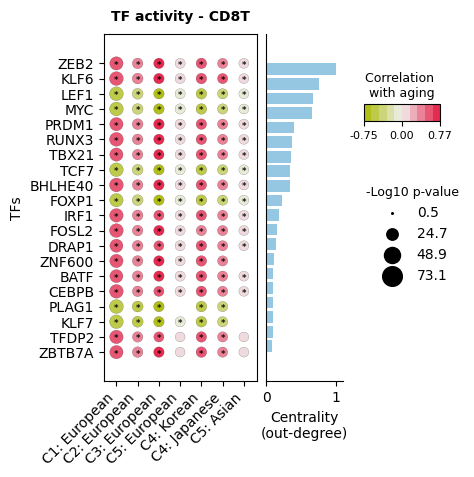

In [6]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

cell_type = 'CD8T'
type = 'bulk'
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=None, width=4,
                            feature_type='tf_activity', sizes=(50, 100), min_degree=4, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

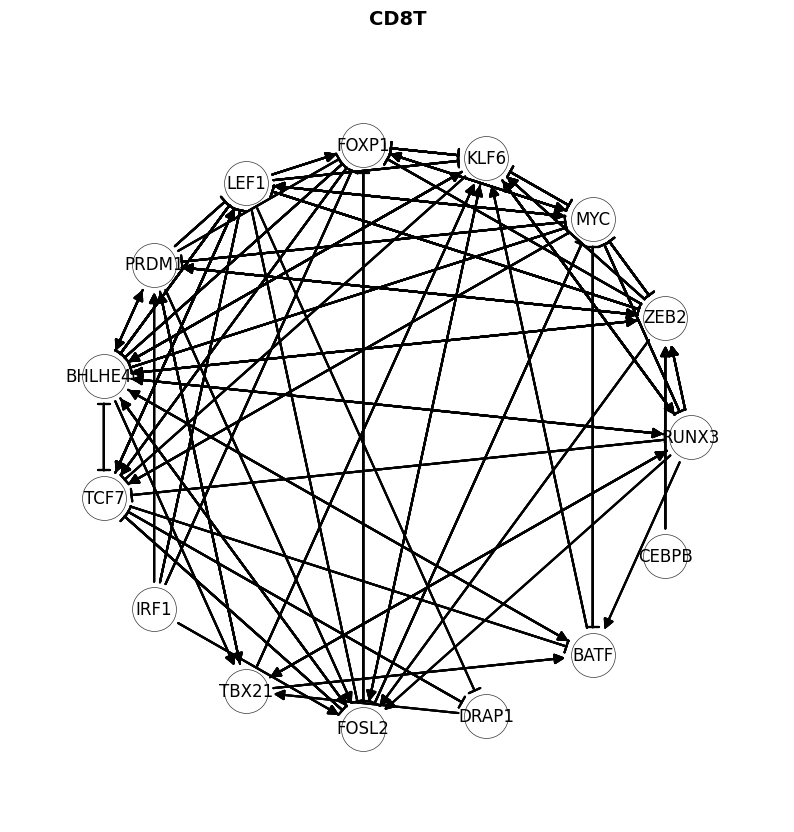

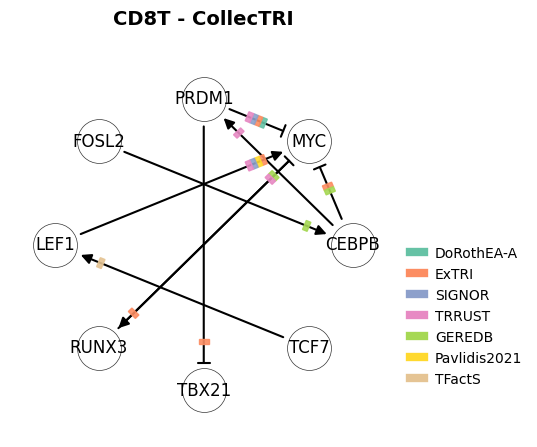

In [9]:
from ciim.src.tf_activity.plots import wrapper_draw_net
wrapper_draw_net(cell_type, datasets_all, features=['ZEB2', 'PRDM1', 'RUNX3', 'BHLHE40', 'FOXP1', 'IRF1', 'FOSL2', 'DRAP1', 'BATF', 'CEBPB', 'TBX21', 'LEF1', 'KLF6', 'BATF', 'MYC', 'TCF7'],
                 min_degree=3, indivitual_net=False, draw_evidence=False, 
                 figsize=(10, 10), figsize_collectri=(5, 5), 
                 offset_evidence=.1, arc_offset=.05, offset_evidence_collectri=.1)

## Modularize the interactions

In [54]:
from ciim.src.tf_activity.helper import retrieve_nets
cell_type = 'CD8T'
stats_sig = retrieve_sig_stats(race='european', type='bulk').drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_t = stats_sig[stats_sig['cell_type'] == cell_type].set_index(['tf'])
sig_tfs = stats_sig_t.index.unique()
print(len(sig_tfs))
min_degree = 3
net = retrieve_nets(datasets_e, cell_type, only_promotor_based=True)

net = net[(net['source'].isin(sig_tfs) & net['target'].isin(sig_tfs))]
# - keep edges with min degree
net['sign'] = np.sign(net['weight'])
net = net.groupby(['source', 'target']).filter(lambda x: len(x) >= min_degree)
degress = net.groupby(['source', 'target', 'sign']).size()
tuple_index = degress[degress >= min_degree].index
net = net.set_index(['source', 'target', 'sign']).loc[tuple_index].reset_index().drop_duplicates(subset=['source', 'target', 'sign'])[['source', 'target', 'sign', 'weight']]

if False: # we do this later on the collapsed 
    net = net.merge(stats_sig[['tf', 'trend']], how='left', left_on=['source'], right_on=['tf']).drop(columns=['tf'])
    net = net.merge(stats_sig[['tf', 'trend']], how='left', left_on=['target'], right_on=['tf'], suffixes=('_source', '_target')).drop(columns=['tf'])

net.head()

102


,source,target,sign,weight
0,AKNA,MYC,-1.0,-0.057552
3,ASCL2,BATF,1.0,0.058077
6,ASCL2,MYC,-1.0,-0.067933
9,BCL11B,FOXP1,1.0,0.097419
13,BCL11B,MYC,1.0,0.073252


In [56]:
df = net.copy()

# Pivot to create source-target matrix
adj_matrix = df.pivot_table(index='source', columns='target', values='sign', fill_value=0)

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# Compute clustering on sources (rows)
source_dist = pdist(adj_matrix, metric='cosine')
source_linkage = linkage(source_dist, method='average')
source_clusters = fcluster(source_linkage, t=0.5, criterion='distance')  # tune `t` to get different granularity

# Same for targets (columns)
target_dist = pdist(adj_matrix.T, metric='cosine')
target_linkage = linkage(target_dist, method='average')
target_clusters = fcluster(target_linkage, t=0.5, criterion='distance')

source_module_map = dict(zip(adj_matrix.index, source_clusters))
target_module_map = dict(zip(adj_matrix.columns, target_clusters))

df['source_module'] = df['source'].map(source_module_map)
df['target_module'] = df['target'].map(target_module_map)

# Updated source module names
from collections import defaultdict

# Get source groups
source_groups = defaultdict(list)
for gene, mod in source_module_map.items():
    source_groups[mod].append(gene)

# Same for targets
target_groups = defaultdict(list)
for gene, mod in target_module_map.items():
    target_groups[mod].append(gene)


source_module_names = {
    mod: '/'.join(sorted(genes))
    for mod, genes in source_groups.items()
}

# Updated target module names
target_module_names = {
    mod: '/'.join(sorted(genes))
    for mod, genes in target_groups.items()
}
df['source_module_name'] = df['source_module'].map(source_module_names)
df['target_module_name'] = df['target_module'].map(target_module_names)

# Collapse
collapsed_net = df.groupby(['source_module_name', 'target_module_name'])['sign'].mean().reset_index()
collapsed_net.rename(columns={'source_module_name': 'source', 'target_module_name': 'target', 'sign': 'weight'}, inplace=True)

# - sumarize the trends for the collapsed net
def summarize_trend(x):
    'Assigns one trend for multiple tfs'
    unique_trends = np.unique([stats_sig_t.loc[tf]['trend'] for tf in x.split('/')])
    if len(unique_trends)==1:
        return unique_trends[0]
    else:
        return 'Mixed'

source_trends = []
target_trends = []

for i, row in collapsed_net.iterrows():
    source = row['source']
    target = row['target']

    source_trend = summarize_trend(source)
    target_trend = summarize_trend(target)

    source_trends.append(source_trend)
    target_trends.append(target_trend)
collapsed_net['trend_source'] = source_trends
collapsed_net['trend_target'] = target_trends
collapsed_net.head()

,source,target,weight,trend_source,trend_target
0,AKNA/ASCL2,BATF,1.0,Increase in aging,Increase in aging
1,AKNA/ASCL2,FOXP1/MYC,-1.0,Increase in aging,Decrease in aging
2,BCL11B,FOXP1/MYC,1.0,Decrease in aging,Decrease in aging
3,BHLHE40,KLF6/ZEB2,1.0,Increase in aging,Increase in aging
4,BHLHE40,LEF1,-1.0,Increase in aging,Decrease in aging


In [58]:
!ls 

net_sig_onlyTFs_CD8T.csv	   net_sig_onlyTFs_Tem_Temra_CD8.csv
net_sig_onlyTFs_Tcm_Naive_CD8.csv  net_sig_onlyTFs_Tem_Trm_CD8.csv


In [ ]:
collapsed_net.to_csv(f'../output/nets/collapsed_net_{cell_type}.csv', index=False)

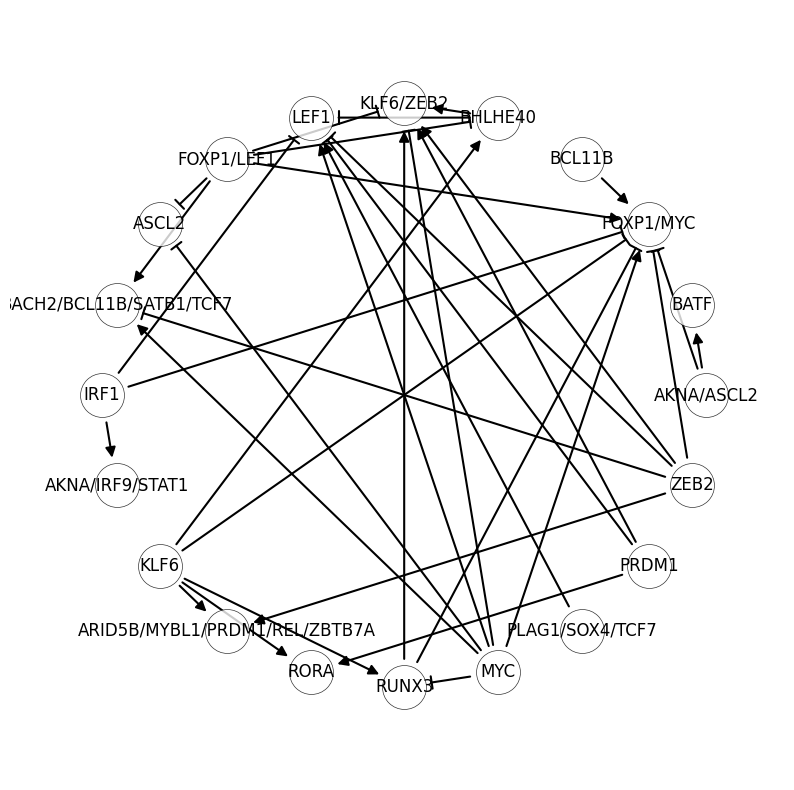

In [57]:
figsize = (10, 10)
draw_evidence = False
offset_evidence = 0.1
arc_offset = 0.05
plot_net_nx(collapsed_net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)

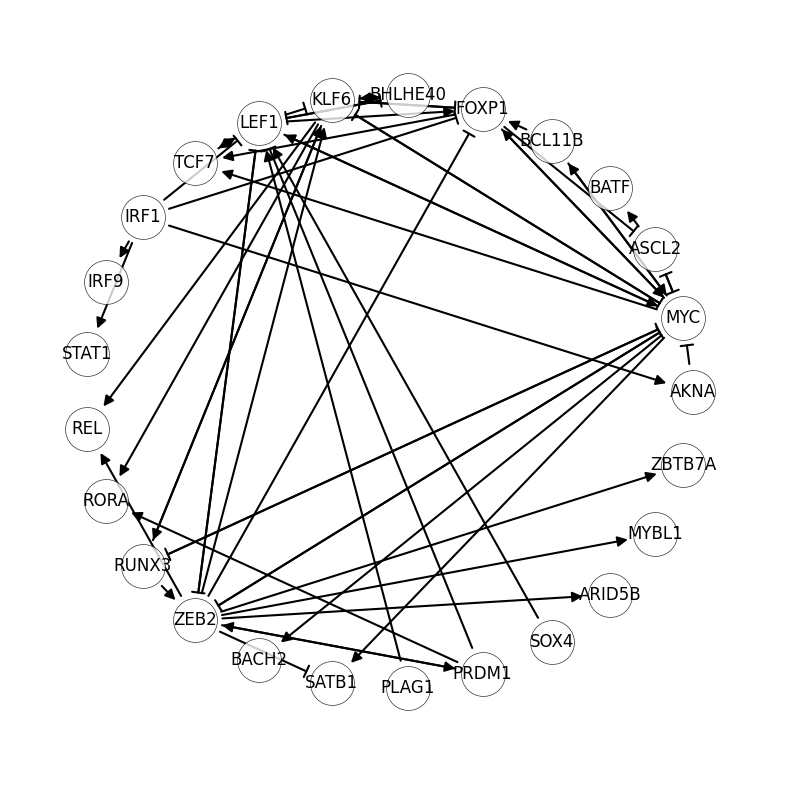

In [20]:

plot_net_nx(net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)

## Stats

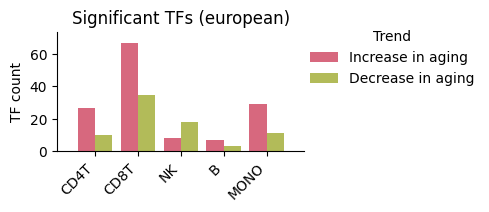

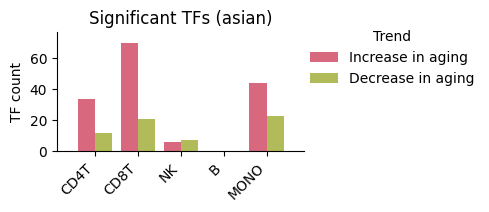

In [32]:
for race in ['european', 'asian']:
    stats = retrieve_sig_stats(type='bulk', race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
    # plt.savefig(f'../output/tf_activity/trends.png', dpi=300)
    stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
    plot_sig_tfs_stats(stats, figsize=(5, 2))
    plt.title(f'Significant TFs ({race})')

## Identify sig networks

In [33]:
from ciim.src.tf_activity.helper import extract_sig_network

type = 'bulk'


if True:
    for race in ['european', 'asian']:
        extract_sig_network(type, race)

CD4T
CD8T
NK
B
MONO
CD4T
CD8T
NK
B
MONO


In [39]:
cell_type = 'CD8T'
type = 'bulk'
race = 'european'
tfs = ['JUND', 'TCF7', 'MYC', 'BACH2']


sig_nets = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
sig_net = sig_nets[sig_nets['cell_type']==cell_type]
# sig_net = sig_net[(sig_net['source'].isin(tfs))]
sig_net['sign'] = np.sign(sig_net['weight'])
sig_net.shape

(5683, 9)

### Network topology

In [106]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

nets = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')

In [68]:
# nets['cell_type'].unique()

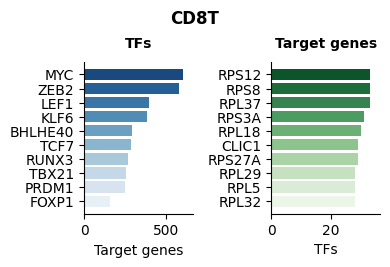

In [107]:
from ciim.src.tf_activity.plots import plot_net_degrees

for cell_type in ['CD8T']:
    net = nets[nets['cell_type'] == cell_type]
    plot_net_degrees(net)
    plt.suptitle(f'{cell_type}', fontsize=12, y=1.05, fontweight='bold')
    

## Shared sig TFs between cell types

In [34]:
stats_sig = retrieve_sig_stats(type, race='european')

['CD8T', 'MONO', 'CD4T', 'NK', 'B']


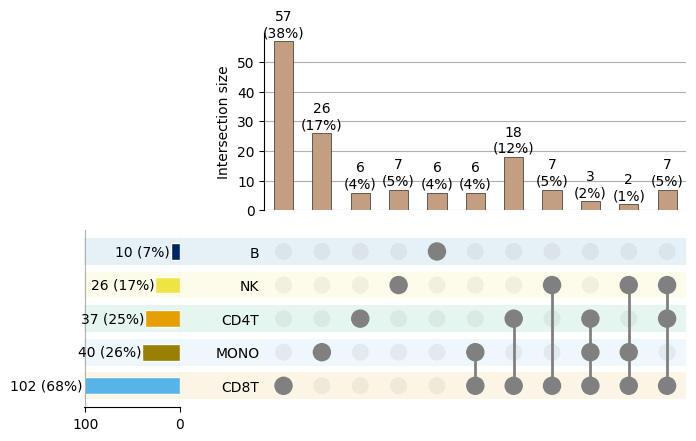

In [35]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=2, color_map=palette_cell_types)
# plt.savefig(f'../output/tf_activity/interactions.png', dpi=300)
# plt.title('', pad=40)

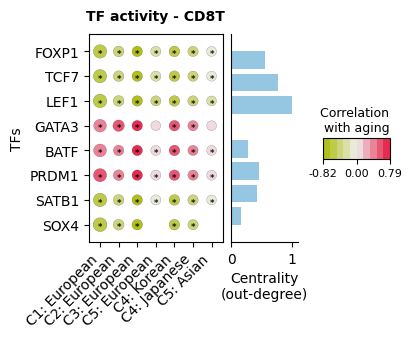

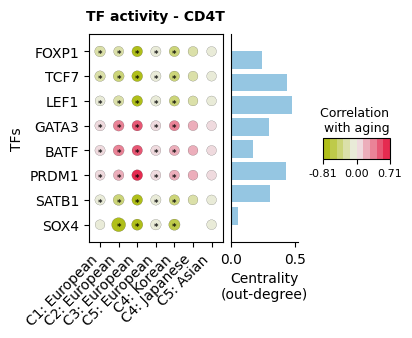

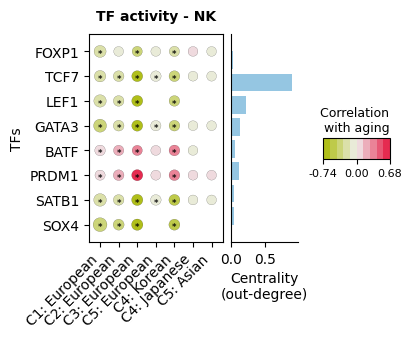

In [36]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index
type = 'bulk'
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

## Shared sig TFs between CD8T and CD4T

(12,)


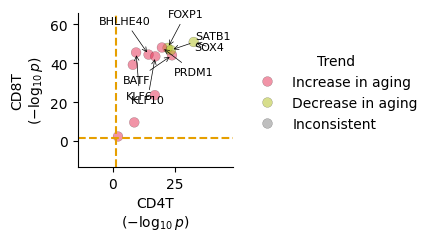

In [29]:
from ciim.src.tf_activity.plots import plot_joint_scatter

interaction_main_ts_df = interaction_main_df[['CD4T', 'CD8T']]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
sig_tfs_ts = np.setdiff1d(sig_tfs_ts, degree3_tfs)
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.5, y=0.3)

## GSEA

In [37]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
type = 'bulk'
races = ['european', 'asian']

pathway_scores_store = []
for race in races:
    stats_sig = retrieve_sig_stats(type, race=race)
    pathway_scores = pathway_analysis_wrapper(stats_sig)
    pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["Adjusted P-value"])
    pathway_scores['race'] = race
    pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

cell_type: CD4T, trend: Increase in aging, n tfs: 27
(5, 10)
cell_type: CD4T, trend: Decrease in aging, n tfs: 10
(2, 10)
cell_type: CD8T, trend: Increase in aging, n tfs: 67
(8, 10)
cell_type: CD8T, trend: Decrease in aging, n tfs: 35
(2, 10)
cell_type: NK, trend: Increase in aging, n tfs: 8
(0, 10)
cell_type: NK, trend: Decrease in aging, n tfs: 18
(10, 10)
cell_type: B, trend: Increase in aging, n tfs: 7
(0, 10)
cell_type: B, trend: Decrease in aging, n tfs: 3
(4, 10)
cell_type: MONO, trend: Increase in aging, n tfs: 29
(3, 10)
cell_type: MONO, trend: Decrease in aging, n tfs: 11
(4, 10)
cell_type: CD4T, trend: Increase in aging, n tfs: 34
(9, 10)
cell_type: CD4T, trend: Decrease in aging, n tfs: 12
(7, 10)
cell_type: CD8T, trend: Increase in aging, n tfs: 70
(7, 10)
cell_type: CD8T, trend: Decrease in aging, n tfs: 21
(9, 10)
cell_type: NK, trend: Increase in aging, n tfs: 6
(0, 10)
cell_type: NK, trend: Decrease in aging, n tfs: 7
(4, 10)
cell_type: MONO, trend: Increase in aging,

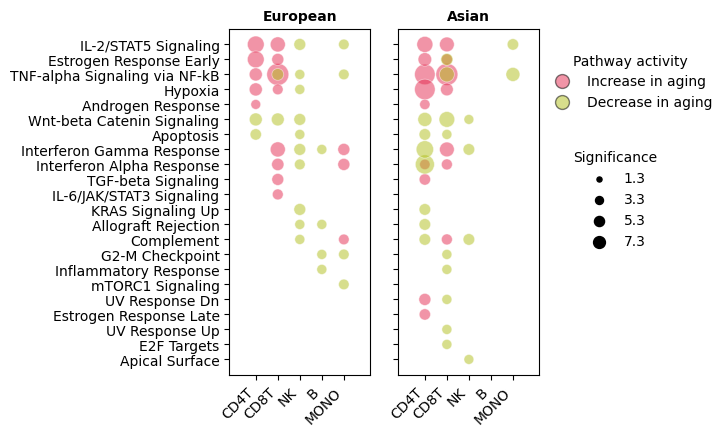

In [38]:
from ciim.src.tf_activity.plots import dotplot_category_color
    
fig, axes = plt.subplots(1, len(races), figsize=(2*len(races), 4.5), sharey=True)
for i, race in enumerate(races):
    ax = axes[i] if len(races)>1 else axes
    pathway_scores = pathway_scores_all[pathway_scores_all['race']==race]
    pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
    if i == len(races)-1:
        show_color_legend = True
        show_size_legend = True
    else:
        show_color_legend = False
        show_size_legend = False
    dotplot_category_color(pathway_scores, 
                ax, 
                color_col='trend', 
                size_col='neg_log10_adj_pval', 
                x='cell_type', 
                y='Term', 
                palette=palette_trend_2, sizes=(50, 250),
                show_color_legend=show_color_legend, 
                show_size_legend=show_size_legend,
                size_legend_title='Significance',
                color_legend_title='Pathway activity',
                size_legend_loc=(1.2, 0.35),
                color_legend_loc=(1.02, 0.75),
                y_label='',
                alpha=0.5)
    ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [33]:
pathway_scores['Term'].unique()

array(['IL-2/STAT5 Signaling', 'Hypoxia', 'Estrogen Response Early',
       'TNF-alpha Signaling via NF-kB', 'Androgen Response',
       'Wnt-beta Catenin Signaling', 'Apoptosis', 'G2-M Checkpoint',
       'KRAS Signaling Up', 'Interferon Gamma Response',
       'TGF-beta Signaling', 'Unfolded Protein Response', 'Complement',
       'Estrogen Response Late', 'UV Response Up', 'p53 Pathway',
       'E2F Targets', 'Allograft Rejection', 'Inflammatory Response',
       'Interferon Alpha Response', 'UV Response Dn', 'mTORC1 Signaling'],
      dtype=object)

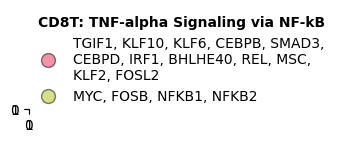

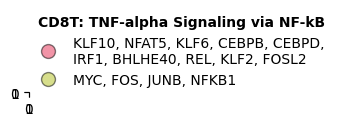

In [40]:
# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'CD8T'

def explode_bifurcation_term(cell_type, term):
    pathway_scores_t = pathway_scores[
        (pathway_scores['Term'] == term) &
        (pathway_scores['cell_type'] == cell_type)
    ]
    
    if pathway_scores_t.empty:
        print(f"No data found for cell type '{cell_type}' and term '{term}'")
        return

    df = (
        pathway_scores_t
        .groupby('trend')['Genes']
        .apply(lambda x: ', '.join(x))
        .reset_index(name='Genes')
        .set_index('trend')
    )

    pp_dict = {}
    every_n_words = 5

    for trend in df.index:
        genes = df.loc[trend, 'Genes'].split(';')
        if trend == 'Increase in aging':
            wrapped = ', \n'.join(
                [', '.join(genes[i:i + every_n_words]) for i in range(0, len(genes), every_n_words)]
            )
        else:
            wrapped = ', '.join(genes)
        pp_dict[trend] = wrapped

    # Actual plot
    from matplotlib.lines import Line2D
    alpha = 0.5
    plt.figure(figsize=(0, 0))

    # Create legend handles only for present trends
    color_legend = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
               markersize=10, label=pp_dict[trend], alpha=alpha)
        for trend, color in palette_trend_2.items()
        if trend in pp_dict
    ]

    legend = plt.legend(
        title=f'{cell_type}: {term}',
        title_fontsize=10,
        fontsize=10,
        handles=color_legend,
        loc=(1, .1),
        frameon=False
    )
    legend.get_title().set_fontweight('bold')
for race in races:
    pathway_scores = pathway_scores_all[pathway_scores_all['race']==race]
    explode_bifurcation_term(cell_type, term)


In [41]:
features = pathway_scores_all[(pathway_scores_all['Term']==term) & (pathway_scores_all['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()

True


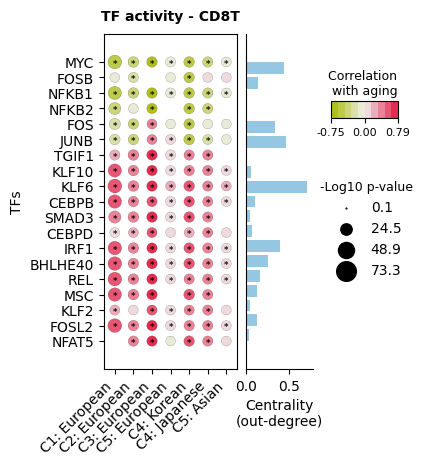

In [42]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


# Minor cell types

## Heatmap

In [2]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
race='european'
stats_store = []
for type in ['bulk', 'bulk_minor']:
    stats_tf = pd.read_csv(f'../output/tf_activity/stats_features_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    stats_tf['major_cell_type'] = stats_tf['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['major_cell_type', 'cell_type', 'tf', 'slope', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf'])

# - plot
stats_all_combined['major_cell_type'] = stats_all_combined['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))


In [3]:
ordered_cell_names = ['CD4T',
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'CD8T',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'B',
                    'Memory_B',
                    'Naive_B',
                    ]
stats_all_combined['cell_type'] = pd.Categorical(stats_all_combined['cell_type'], categories=ordered_cell_names, ordered=True)

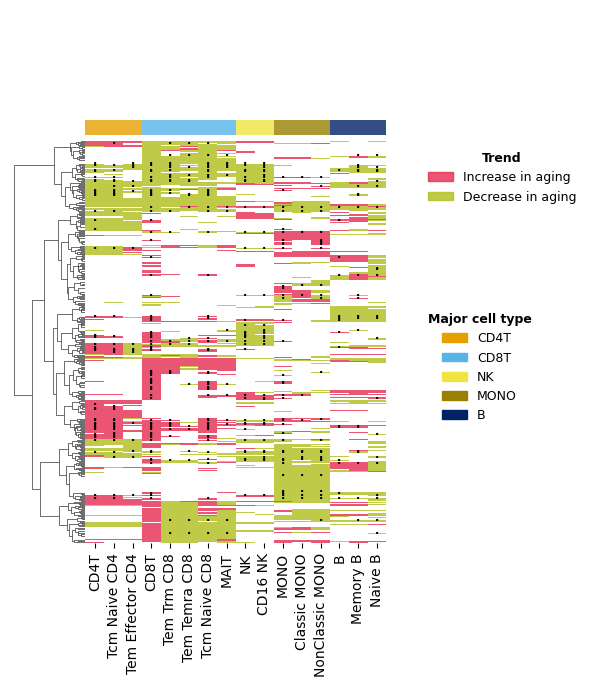

In [4]:
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
heamap_plot_minor_cell_types(stats_all_combined, palette=palette_cell_types, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

## Interaction of subtypes

['Tcm_Naive_CD8', 'Tem_Trm_CD8', 'Tem_Temra_CD8']


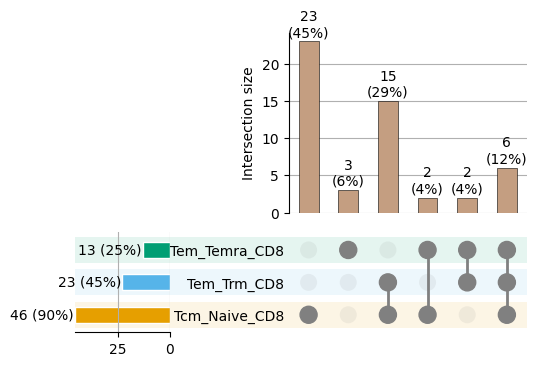

In [6]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
type = 'bulk_minor'
race = 'european'

minor_types = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8',]

stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig = stats_sig[stats_sig['cell_type'].isin(minor_types)]
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=2, color_map=None)

In [8]:
interaction_main_df[interaction_main_df.sum(axis=1)==3].index

Index(['BCL11B', 'RUNX2', 'BACH2', 'BATF', 'KLF7', 'GATA3'], dtype='object')

(21,)


IndexError: index 12 is out of bounds for axis 0 with size 12

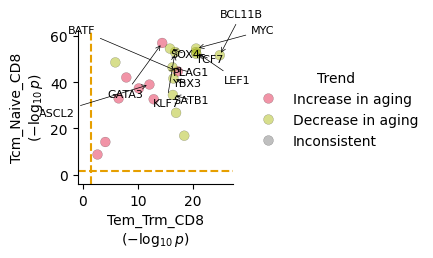

In [11]:
from ciim.src.tf_activity.plots import plot_joint_scatter

vars = ['Tem_Trm_CD8',
                'Tcm_Naive_CD8']
interaction_main_ts_df = interaction_main_df[vars]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=vars, annotate=True, ax=ax)
ax.margins(x=0.5, y=0.3)

## Other

True


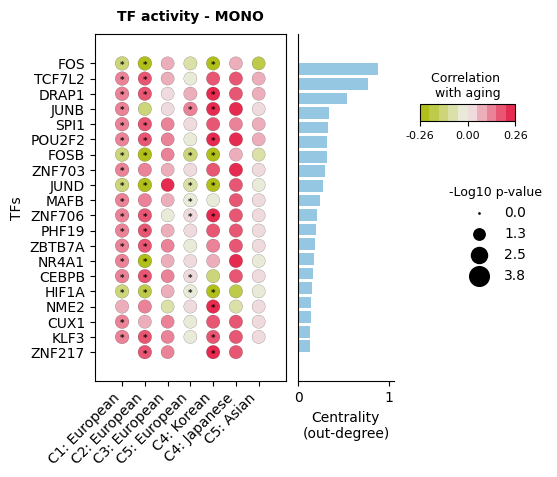

In [33]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
cell_type = 'MONO'
type = 'bulk'

plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=None, feature_type='tf_activity', sizes=(90, 100), width=5, margins={'x': 0.2, 'y': 0.1})
# plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=None, feature_type='gene_expression', sizes=(90, 100), width=4, margins={'x': 0.1, 'y': -.1})

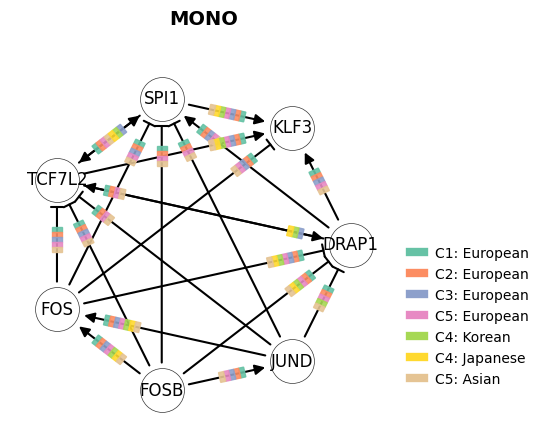

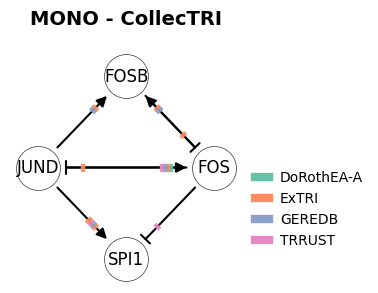

In [34]:
from ciim.src.tf_activity.plots import wrapper_draw_net
cell_type = 'MONO'
type = 'bulk'
wrapper_draw_net(cell_type, datasets_all, features=['FOS', 'TCF7L2', 'DRAP1', 'SPI1', 'FOSB', 'JUND', 'KLF3'], min_degree=3, indivitual_net=False, draw_evidence=True, figsize=(5, 5), figsize_collectri=(3, 3), 
                 offset_evidence=.1, arc_offset=.05, offset_evidence_collectri=.15)

### Cell type proportions

In [30]:
obs_dict = {dataset:ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad', backed='r').obs for dataset in datasets}

NameError: name 'datasets' is not defined

In [92]:
type = 'bulk_minor'
stats_minor = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')
stats_minor_sig = retrieve_valid_stats(type)
stats_minor_sig.head()

,tf,p_value,slope,dataset,cell_type,age_group,condition,slope_condition,values_case,values_control,adj_p_value,meta_p,meta_p_adj,neg_log10_adj_pval,trend,analysis,p_value_adj
11556,ANXA1,5.466096e-11,0.359625,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,5.466096e-11,1.610001e-09,8.793174,Increase in aging,validation,NaN
11558,ARID5B,7.798596e-06,0.249681,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,7.798596e-06,2.091442e-05,4.679554,Increase in aging,validation,NaN
11559,BACH2,1.640360e-08,-0.312371,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,1.640360e-08,1.209766e-07,6.917299,Decrease in aging,validation,NaN
11560,BATF,1.756890e-11,0.368155,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,7.580904e-07,3.194810e-06,5.495555,Increase in aging,validation,NaN
11562,BCL11B,3.421349e-04,-0.201148,data7_allTPs_jalil,Tcm_Naive_CD4,NaN,NaN,NaN,NaN,NaN,NaN,3.421349e-04,6.728652e-04,3.172072,Decrease in aging,validation,NaN


### Low-dimensional plot

In [93]:
# - 
sig_tf_size = stats_minor_sig[['cell_type', 'tf']].groupby('cell_type').size().reset_index(name='sig_tfs').rename({'cell_type': 'Sub_CT'}, axis=1)
sig_tf_size

,Sub_CT,sig_tfs
0,CD16_NK,7
1,Tcm_Naive_CD4,44
2,Tcm_Naive_CD8,50
3,Tem_Trm_CD8,1


In [94]:
if False:
    !mkdir ../output/tf_activity/umap/
    adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/data1_bulk_minor.h5ad')
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write('../output/tf_activity/umap/data_bulk_minor.h5ad')
else:
    adata = ad.read_h5ad('../output/tf_activity/umap/data_bulk_minor.h5ad')
adata.obs = adata.obs.merge(sig_tf_size, on='Sub_CT', how='left')
adata.obs['sig_tfs'] = adata.obs['sig_tfs'].fillna(0).astype(int)
adata = adata[~adata.obs['Sub_CT'].isna(), :]

In [95]:
# adata.obs['Major_CT'] = adata.obs['Major_CT'].astype(str)
adata.obs['Major_CT'].unique()

['B', 'NK', 'MONO', 'CD8T', 'CD4T']
Categories (5, object): ['B', 'CD4T', 'CD8T', 'MONO', 'NK']

In [ ]:
# - plot the umap of #sig tfs per subtype
from ciim.src.utils.plots import plot_umap

for cell_type in ['CD8T', 'CD4T', 'NK', 'MONO']:
        adata_cell = adata[adata.obs['Major_CT'].isin([cell_type])]
        adata_cell.obs['Sub_CT'] = adata_cell.obs['Sub_CT'].astype(str)
        adata_cell = adata_cell[~adata_cell.obs['Sub_CT'].isna(), :]
        adata_cell = adata_cell[~adata_cell.obs['age'].isna(), :]
        sorted_subtypes = mapping_major_2_minor[cell_type]
        # - sanity check 
        # print([c for c in sorted_subtypes if c not in adata_cell.obs['Sub_CT'].unique()])
        # aaa
        diff = np.setdiff1d(adata_cell.obs['Sub_CT'].unique(), sorted_subtypes)
        if diff.shape[0]>0:
                print(diff)
        # - plot the umap of #sig tfs per subtype  
        
        palette={name: value for name, value in zip(sorted(sorted_subtypes), colors_blind)}
        print(palette)
        fig, ax = plt.subplots(1, 1, figsize=(6, 3))
        # ax = axes[0]
        adata_cell.obs['Sub_CT'] = adata_cell.obs['Sub_CT'].astype(CategoricalDtype(categories=sorted_subtypes, ordered=True))
        print(adata_cell.obs['Sub_CT'].unique())
        plot_umap(adata_cell, color='Sub_CT', ax=ax, s=1, X_label='X_pca', alpha=.9, sort_colors=False,
                bbox_to_anchor=(.9,.1), palette=palette,
                margins=dict(x=.1, y=.1), 
                )  
        ax = axes[1]
        groups = adata_cell.obs['sig_tfs'].unique()
        plot_umap(adata_cell, color='sig_tfs', ax=ax, s=1, X_label='X_pca', alpha=.9, 
                bbox_to_anchor=(.9,.1), 
                margins=dict(x=.1, y=.1), 
                palette={name: value for name, value in zip(sorted(groups), sns.color_palette("viridis", n_colors=len(groups)))},
                legend_title='TFs count',
                )  

        plt.suptitle(f'TFs significantly associated with age ({cell_type})', fontsize=12)
        plt.tight_layout()


AssertionError: Don’t call _normalize_index with non-categorical/string names

# STD

In [58]:
pd.read_csv(f'../output/tf_activity/stats_tfs_sc.csv')

,tf,p_value,slope,dataset,cell_type,age_group,condition,slope_condition,values_case,values_control,adj_p_value
0,ADNP,5.226819e-05,-0.128781,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
1,ANXA1,1.489113e-15,0.250946,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
2,ANXA11,3.954323e-16,0.255876,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
3,APEX1,3.002488e-13,0.230051,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
4,ARID5B,1.822060e-13,0.232105,data1,CD4T,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10880,ZNF581,9.465691e-02,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[1.52272198 1.10979719 1.02750641 1.27967717 1...,[1.7308587 1.13832118 1.02390717 2.30559863 1...,0.133523
10881,ZNF622,1.142740e-03,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[3.00796087 2.93784677 3.01218627 3.58644526 3...,[3.8156539 2.28822334 2.15113002 4.67379409 1...,0.003312
10882,ZNF706,1.629860e-02,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[15.3652678 14.3707387 16.5267336 14.990143...,[17.17229204 15.04296109 12.59231433 18.655654...,0.027552
10883,ZNF90,2.467785e-02,NaN,SLE,MONO,old,systemic lupus erythematosus,True,[ 8.82919807 16.12991171 13.1865046 13.069082...,[12.01867402 8.93440599 10.33188634 13.275075...,0.040279


In [51]:
# - get the stats for bulk of bulk and sc
stats_store = []
for type in ['bulk', 'sc_std']:
    stats_tf = pd.read_csv(f'../output/tf_activity/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    
    stats_tf['type'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'type', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'type', 'is_significant'])

# - plot
stats_all_combined['type'] = stats_all_combined['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=5, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='type', second_col_palette={'Bulk': 'gray', 'STD': 'lightblue'},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'type': 'Analysis'})

FileNotFoundError: [Errno 2] No such file or directory: '../output/tf_activation/stats_tfs_sc_std.csv'

In [73]:
cell_type = 'CD8T'

stats_valid_store = []
for type in ['bulk', 'sc']:
    stats_valid = retrieve_valid_stats(type)
    stats_valid = stats_valid[stats_valid['cell_type'].isin([cell_type])]

    nets = pd.read_csv(f'../output/tf_activity/sig_nets_{type}.csv')
    nets = nets[nets['cell_type'].isin([cell_type])]
    central_tfs = nets.groupby(['source']).size().sort_values(ascending=False).head(40).index.to_numpy()
    stats_valid = stats_valid[stats_valid['tf'].isin(central_tfs)]
    # stats_valid = stats_valid.sort_values('meta_p_adj', ascending=True).head(30)
    stats_valid['type'] = type
    stats_valid['cell_type'] = cell_type
    stats_valid_store.append(stats_valid)
stats_valid_all = pd.concat(stats_valid_store, axis=0)
stats_valid_all['neg_log10_adj_pval'] = -np.log10(stats_valid_all['meta_p_adj'])
stats_valid_all['type'] = stats_valid_all['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))


In [74]:
df_common = stats_valid_all.groupby(['cell_type', 'tf']).size()
tuple_index = df_common[df_common==2].index
stats_valid_all = stats_valid_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

In [54]:
'GATA3' in stats_valid_all['tf'].unique()

False

In [79]:
stats_valid_all['tf'].unique()

array(['RPL35', 'RPL6', 'RPS10', 'RPS4X', 'SATB1', 'TBX21', 'TCF7',
       'TPI1', 'UBB', 'UQCRB', 'XBP1', 'YWHAZ', 'ZBTB38', 'ZEB2',
       'ZNF101', 'ZNF600'], dtype=object)

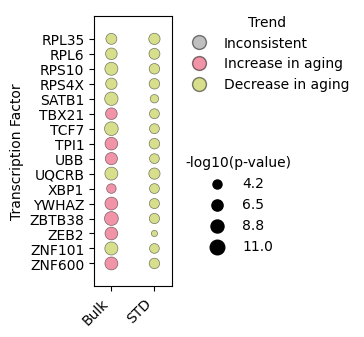

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(1, 3.5))
dotplot(stats_valid_all, ax=ax,
        x='type', y='tf', color_col='trend', size_col='neg_log10_adj_pval', 
        palette=palette_trend, sizes=(20, 100), alpha=.5)
ax.margins(x=0.4, y=0.1)

In [ ]:
read_tf_acts

# Gender


## Overall plot

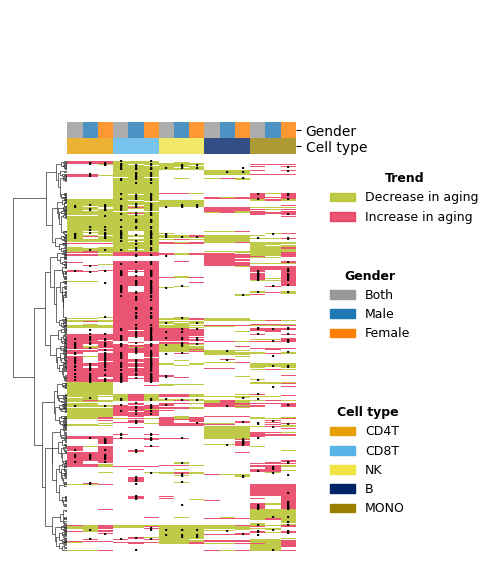

In [65]:
# - get the stats for bulk of both gender
from ciim.src.tf_activity.helper import retrieve_stats_features
stats_store = []
race='european'

for type in ['bulk', 'bulk_M', 'bulk_F']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add valid cases
    stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)
    # stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_sig['tf'])) & (stats_tf['cell_type'].isin(stats_sig['cell_type']))
    
    stats_tf['gender'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'gender', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'gender', 'is_significant'])

# - plot
stats_all_combined['gender'] = stats_all_combined['gender'].map({'bulk': 'Both', 'bulk_F': 'Female', 'bulk_M': 'Male'}).astype(CategoricalDtype(categories=['Both', 'Male', 'Female'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=3, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='gender', second_col_palette={**{'Both': 'gray', **palette_genders}},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'gender': 'Gender'})

## Interactions

In [66]:
# - find tfs with opposite trends
stats_sig_M  = retrieve_sig_stats(type='bulk_M', race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_M['gender'] = 'Male'
stats_sig_F = retrieve_sig_stats(type='bulk_F', race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_F['gender'] = 'Female'
stats_sig_all = pd.concat([stats_sig_M, stats_sig_F])

features_dict = {}
for cell_type in cell_types:
    stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]
    mask = stats_t.groupby('tf')['slope'].apply(lambda x: np.sign(x).nunique() == 2)
    tfs = mask[mask].index.tolist()
    features_dict[cell_type] = tfs

print('tfs with opposite trends: ', features_dict)

# - find tfs sig in one and not the other
features_dict = {}
for cell_type in cell_types:
    stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]    
    mask = stats_t.groupby('tf')['gender'].nunique()
    print(cell_type, mask.value_counts())
    tfs = mask[mask == 1].index.tolist()

    features_dict[cell_type] = tfs

print('tfs sig in one and not the other: ', features_dict)

tfs with opposite trends:  {'CD4T': ['ZNF207'], 'CD8T': [], 'NK': [], 'B': ['HES1'], 'MONO': []}
CD4T gender
1    93
2    30
Name: count, dtype: int64
CD8T gender
1    129
2     85
Name: count, dtype: int64
NK gender
1    41
2    31
Name: count, dtype: int64
B gender
1    49
2     6
Name: count, dtype: int64
MONO gender
1    92
2     6
Name: count, dtype: int64
tfs sig in one and not the other:  {'CD4T': ['AEBP2', 'AKNA', 'ARHGAP35', 'ARID5B', 'BACH2', 'BATF', 'BAZ2A', 'BAZ2B', 'BCL11B', 'BHLHE40', 'BPTF', 'CAMTA1', 'CENPX', 'CREM', 'CSRNP1', 'DDIT3', 'DRAP1', 'E2F3', 'EEA1', 'EGR1', 'ELF1', 'ELK3', 'EOMES', 'FLI1', 'FOS', 'FOSL2', 'FOXN2', 'FOXN3', 'FOXP1', 'GATA3', 'GPBP1', 'HIVEP3', 'IKZF2', 'IRF3', 'IRF4', 'JAZF1', 'JUN', 'JUNB', 'JUND', 'KDM2A', 'KLF10', 'KLF13', 'KLF2', 'KLF6', 'KLF9', 'KMT2A', 'LEF1', 'MAF', 'MAX', 'MAZ', 'MLXIP', 'MXD4', 'MYBL1', 'MYC', 'NCOA1', 'NFATC2', 'NFATC3', 'NR1D1', 'NR1D2', 'NR3C1', 'NR4A1', 'NR4A2', 'PHF21A', 'PIN1', 'PLSCR1', 'POU2F2', 'PRDM1', 'RBCK

In [71]:
stats_sig = retrieve_sig_stats(type='bulk_M', race=race)
stats_sig[(stats_sig['tf']=='ZNF207') & (stats_sig['cell_type']=='CD4T')].head()

,tf,p_value,slope,p_value_adj,condition,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,trend,analysis
329,ZNF207,0.234574,0.073128,0.358450,healthy,data7_allTPs_jalil,CD4T,1.442386e-18,3.243869e-18,17.488937,Increase in aging,european
589,ZNF207,0.508280,0.121335,0.580228,healthy,data12,CD4T,1.442386e-18,3.243869e-18,17.488937,Increase in aging,european
714,ZNF207,0.000000,0.000552,0.000000,healthy,SLE_European,CD4T,1.442386e-18,3.243869e-18,17.488937,Increase in aging,european


Only 6 datasets are available in the stats.
Only 6 datasets are available in the stats.
Only 5 datasets are available in the stats.


Text(0.5, 1.2, 'Male')

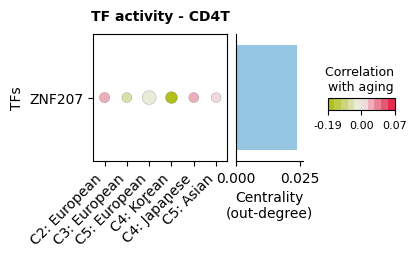

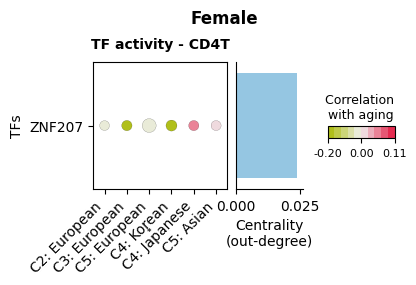

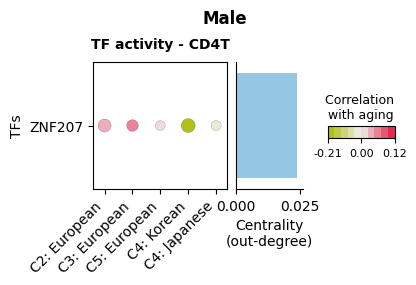

In [72]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
cell_type='CD4T'

features = ['ZNF207']


plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plot_features_vs_datasets(cell_type=cell_type, type='bulk_F', datasets=datasets_all, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Female', fontsize=12, y=1.2, fontweight='bold')
plot_features_vs_datasets(cell_type=cell_type, type='bulk_M', datasets=datasets_all, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Male', fontsize=12, y=1.2, fontweight='bold')

In [ ]:
plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type=feature_type, type=type, datasets=datasets_all, show_cbar=True)


# Trajectory plot: TF acitvity with age


(981, 76)
(313, 185)
(61, 172)
(150, 79)
(981,) (981,) (981,)
(313,) (313,) (313,)
(61,) (61,) (61,)
(150,) (150,) (150,)


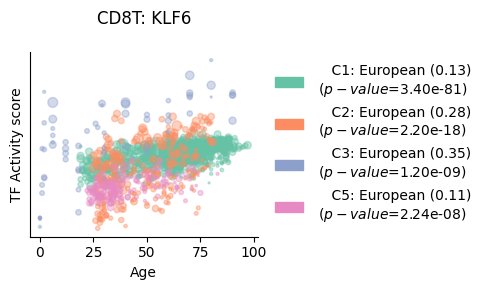

In [20]:

from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'../output/tf_activity/trends_{cell_type}_case.png', dpi=300)

In [41]:
data_df['cohort'].unique()

['C3: European', 'C5: European', 'C2: European', 'C1: European']
Categories (4, object): ['C3: European' < 'C5: European' < 'C2: European' < 'C1: European']

Spearman correlations per cohort:

Meta-analysis combined p-value (Fisher's method): 6.258559317395964e-94


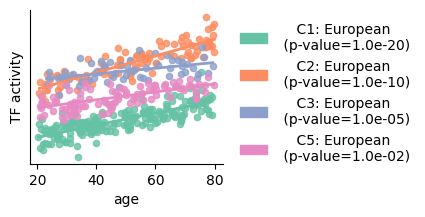

In [51]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, combine_pvalues
import matplotlib.pyplot as plt

# Step 1: Generate random data
np.random.seed(42)  # for reproducibility

n_samples_list = [200, 100, 60, 100]  # number of samples per cohort
cohorts = datasets_e

data = []

# Define base slope and intercept
base_slope = 0.05
base_intercept = 0.5

for i,cohort in enumerate(cohorts):
    n_samples = n_samples_list[i]
    ages = np.random.uniform(20, 80, size=n_samples)
    
    # Slight random shifts in slope and intercept for each cohort
    slope_shift = np.random.normal(0, 0.02)
    intercept_shift = np.random.normal(0, 4)
    
    tf_activity = (base_slope + slope_shift) * ages + (base_intercept + intercept_shift)
    tf_activity += np.random.normal(0, 0.5, size=n_samples)  # add noise
    
    cohort_df = pd.DataFrame({
        'cohort': cohort,
        'age': ages,
        'tf_activity': tf_activity
    })
    
    data.append(cohort_df)

# Combine into one dataframe
data_df = pd.concat(data, ignore_index=True)
data_df['cohort'] = data_df['cohort'].astype(pd.CategoricalDtype(categories=cohorts, ordered=True))
# Step 2: Calculate Spearman correlation per cohort
results = []
for cohort in cohorts:
    subset = data_df[data_df['cohort'] == cohort]
    corr, pval = spearmanr(subset['age'], subset['tf_activity'])
    results.append({'cohort': cohort, 'spearman_corr': corr, 'pval': pval})

results_df = pd.DataFrame(results)
print("Spearman correlations per cohort:")
_, combined_pval = combine_pvalues(results_df['pval'])

print("\nMeta-analysis combined p-value (Fisher's method):", combined_pval)

# (Optional) Step 4: Plotting
import seaborn as sns
fig, ax = plt.subplots(figsize=(2.5, 2))
for cohort in data_df['cohort'].unique():
    subset = data_df[data_df['cohort'] == cohort]
    sns.regplot(data=subset, x='age', y='tf_activity', ax=ax, 
                scatter_kws={'s': 20}, line_kws={'linewidth':2},
                color=palette_datasets[cohort], label=cohort, ci=None)

# ax.legend(title='Cohort', loc=(1.1, .2), frameon=False)
p_values = [1E-20, 1E-10, 1E-5, 1E-2]
legend_handles = []
for i, d in enumerate(cohorts):
    p_value = p_values[i]
    legend_label = '    ' + surrogate_names[d] +'\n' + r' (p-value=' + "{:.1e}".format(p_value) + ")"

    handle = mpatches.Patch(color=palette_datasets[d], label=legend_label)
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_yticks([])
ax.set_ylabel('TF activity')
plt.show()

## TF activity trend vs expression trend in aging


In [52]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, retrieve_adata

stats_store = []
for dataset in datasets:
    adata = retrieve_adata(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activity/activation_vs_expression.png', dpi=300)

ImportError: cannot import name 'determine_stats' from 'ciim.src.tf_activity.helper' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/helper.py)